In [50]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv("smartcart_customers.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# Data Pre-Processing

## 1. Handling Missing Values

In [53]:
df["Income"] = df["Income"].fillna(df["Income"].median())

## 2. Feature Engineering

#### A. Year_Birth => Age 

In [54]:
# we will crete age bec. it is ore meaningful than year of birth 

df["Age"] = 2026-df['Year_Birth']

#### B. Dt_Customer => Customer_Tenure_Days

In [55]:
# Date when customer enrolled with SmartCart (Dt_Customer) is not a meaningfull feature so get no. of days from that to see how often customer is visiting 
# we will get the days by sub. Dt_Customer by max date in the list 

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

reference_date = df['Dt_Customer'].max()

df['Customer_Tenure_Days'] = (reference_date - df['Dt_Customer']).dt.days

#### C. Create df ['Total_Spending']

In [56]:
df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

#### D. Create df ['Total_Childrean']

In [57]:
df['Total_Childrean'] = df['Kidhome'] + df['Teenhome']

#### E. Education

In [58]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [59]:
df['Education'] = df['Education'].replace({
    "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate", "PhD" : "Postgraduate"
})

In [60]:
df['Education'].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

#### F. Marital_Status

In [61]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [62]:
df['Living_with'] = df['Marital_Status'].replace({
    "Married" : "Partner", "Together" : "Partner",
    "Single" : "Alone", "Divorced" : "Alone", "Widow" : "Alone", "Absurd" : "Alone", "YOLO" : "Alone"
})

In [63]:
df['Living_with'].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

#### G. Drop Columns 

In [64]:
cols = ['ID', 'Year_Birth','Marital_Status', 'Kidhome', 'Teenhome', 'Dt_Customer']
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [65]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrean,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [66]:
df_cleaned.shape

(2240, 15)

## EDA

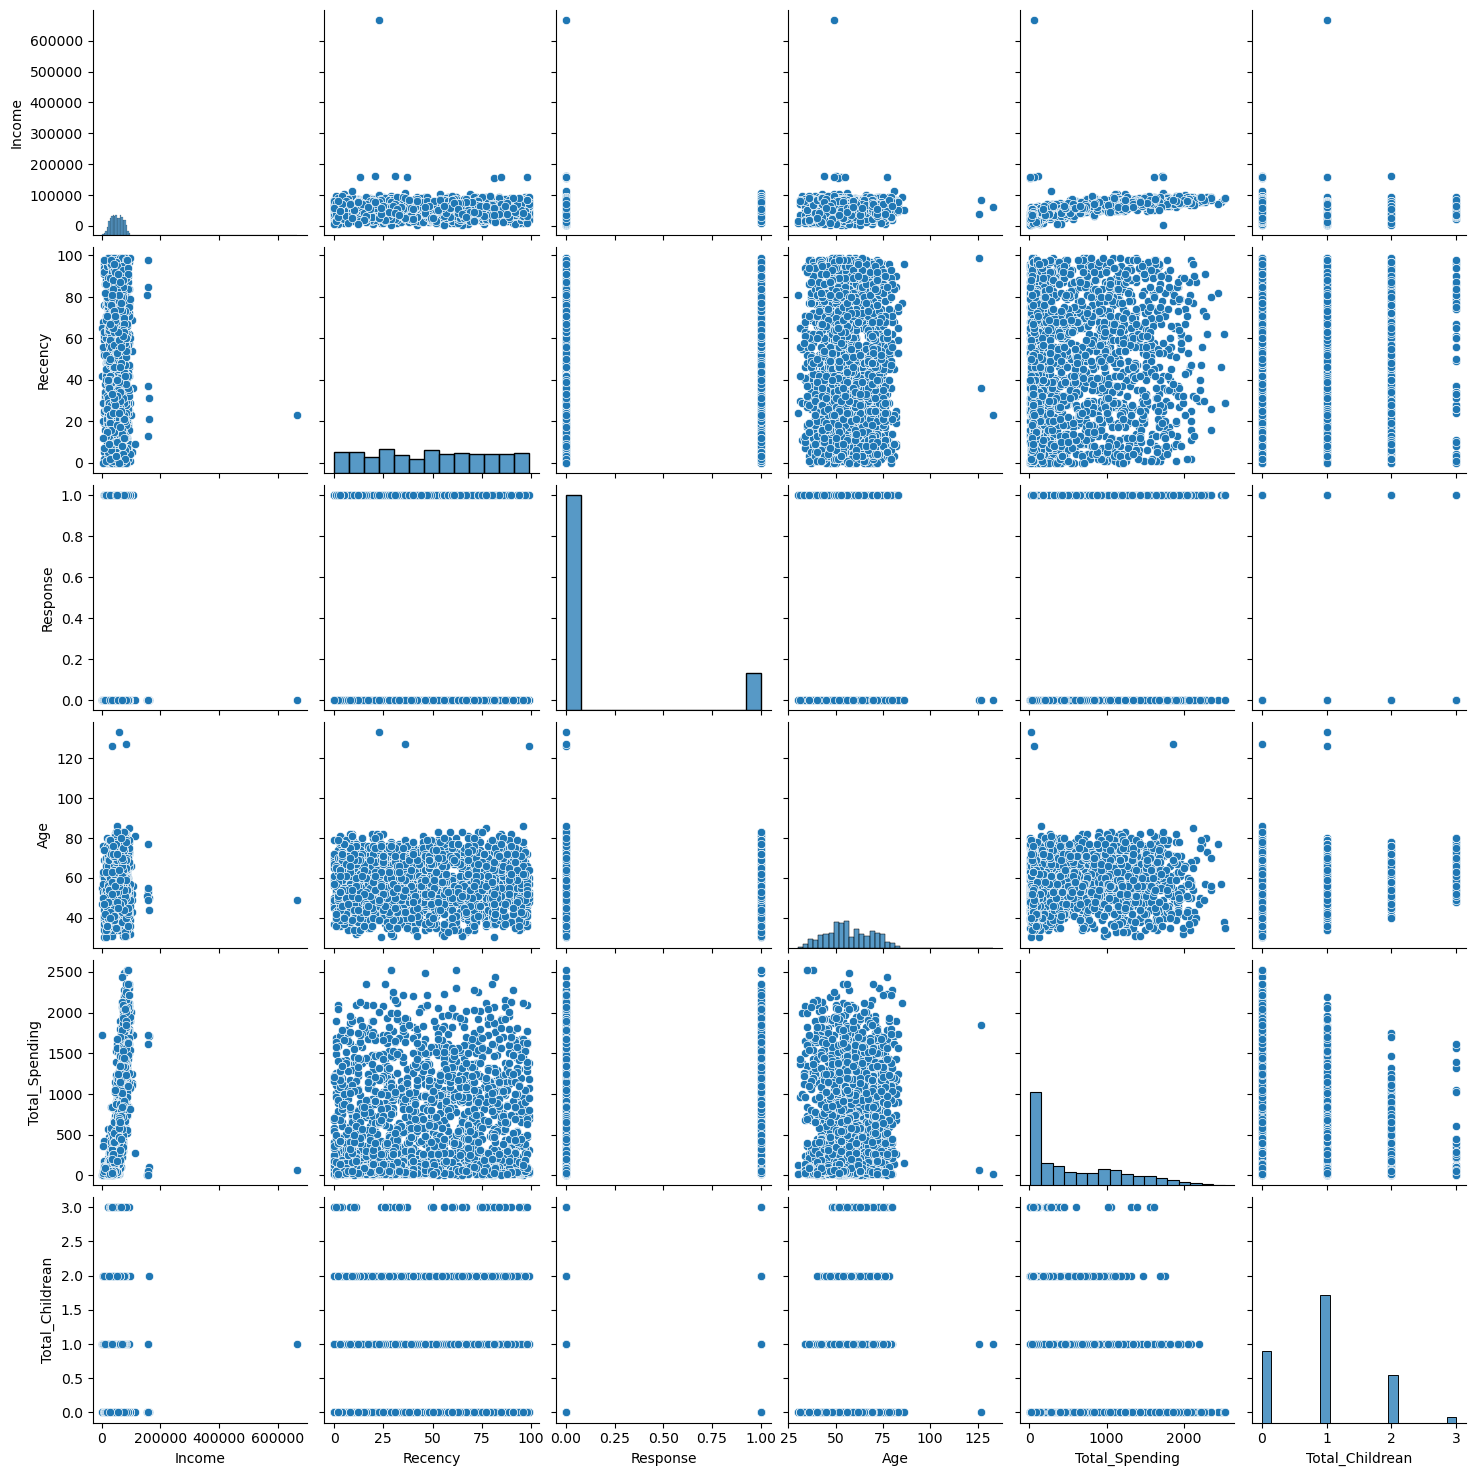

In [67]:
# lets detect outlier

cols = ['Income', 'Recency', 'Response', 'Age', 'Total_Spending', 'Total_Childrean']

sns.pairplot(df_cleaned[cols])

In [68]:
print("data with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned['Age'] < 90)]
df_cleaned = df_cleaned[(df_cleaned['Income'] < 600_000)]

print("data without outliers:", len(df_cleaned))

data with outliers: 2240
data without outliers: 2236


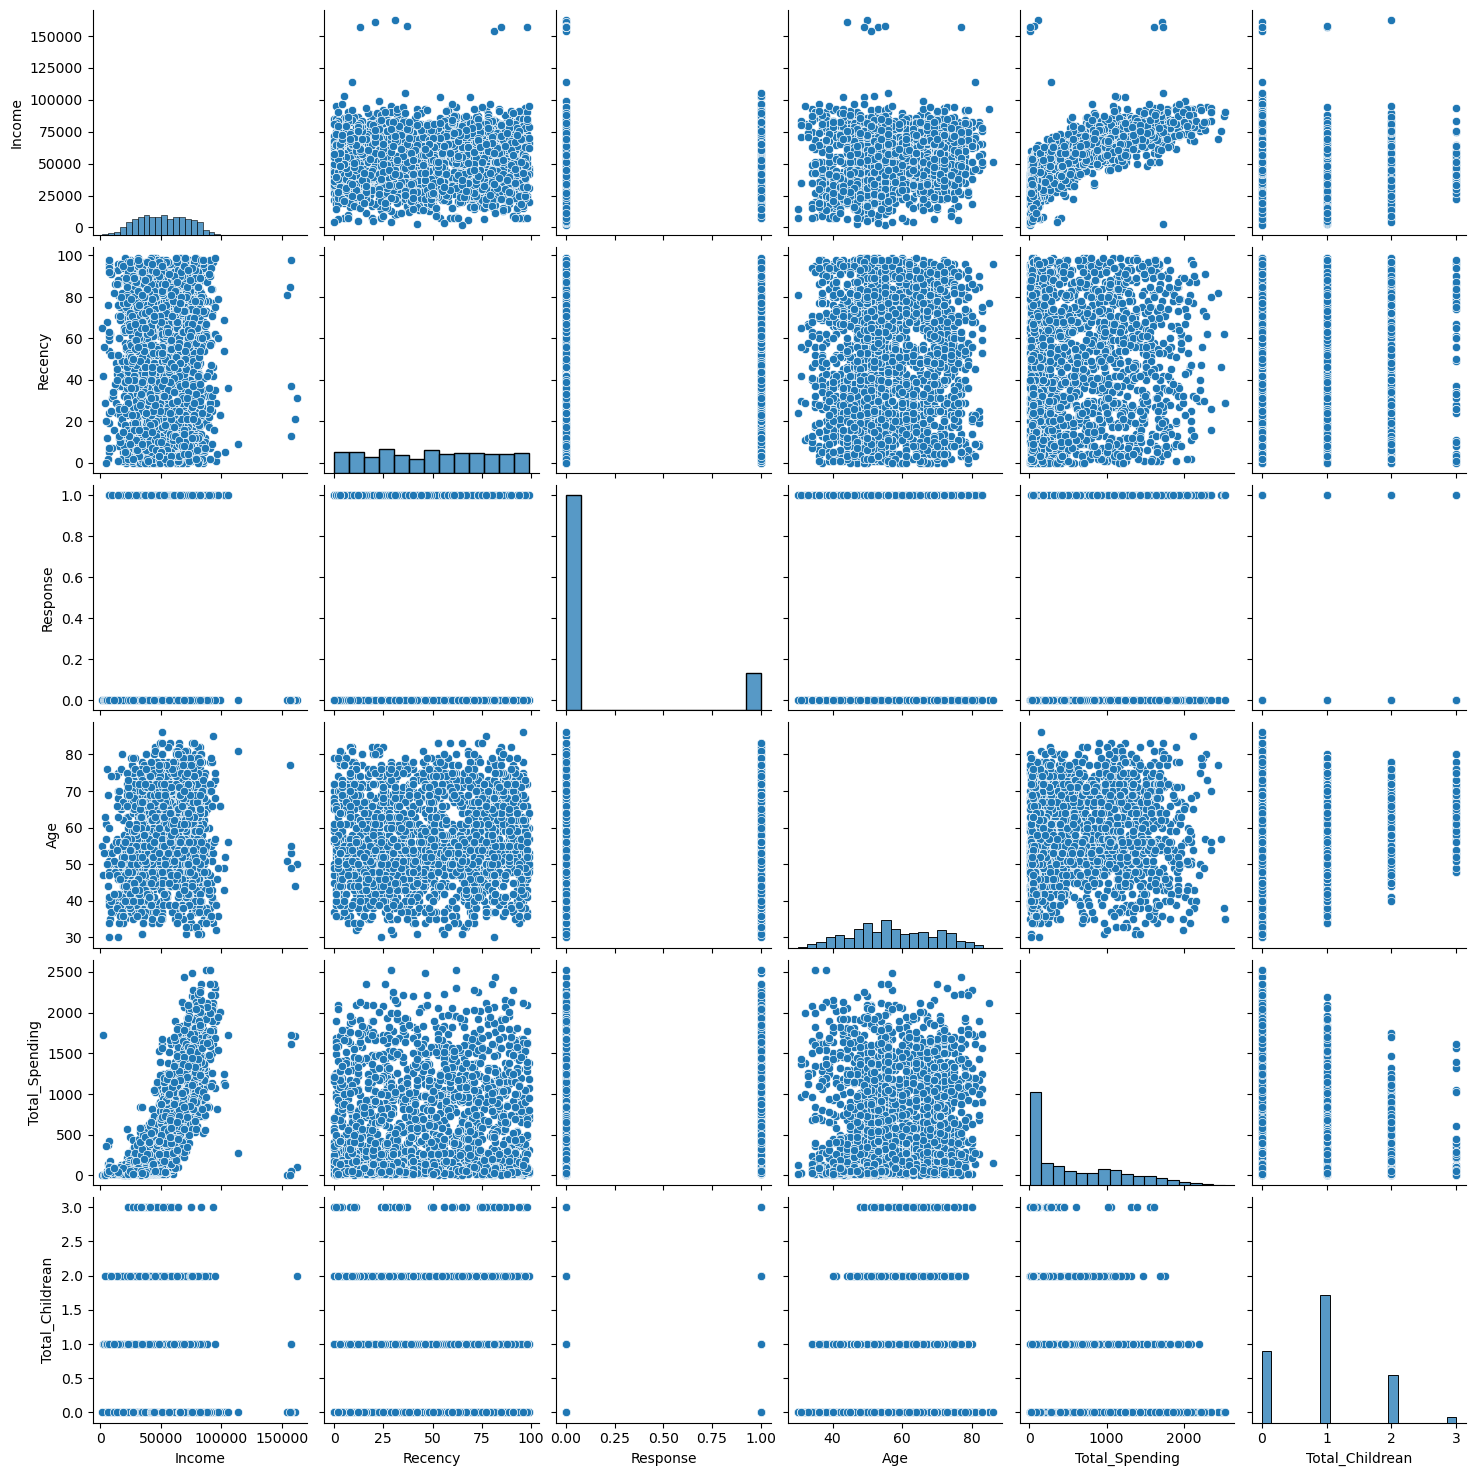

In [69]:
sns.pairplot(df_cleaned[cols])

In [70]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

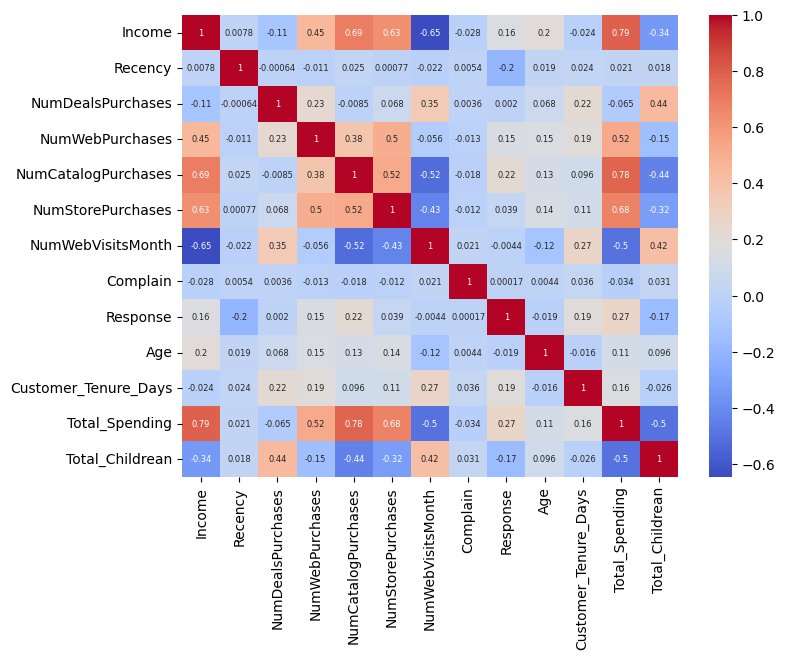

In [71]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size': 6},
    cmap="coolwarm"
)

In [72]:
''' Conclution of HeatMap :

    1. +ve correlation
        0.79 = Income -> Total_Spending
        0.69 = Income -> NumCatalogPurchases
        0.63 = Income -> NumStorePurchases
        0.78 = Total_Spending -> NumCatalogPurchases
        0.68 = Total_Spending -> NumStorePurchases

    2. -ve correlation
        -0.65 = Income -> NumWebVisitsMonth '''

' Conclution of HeatMap :\n\n    1. +ve correlation\n        0.79 = Income -> Total_Spending\n        0.69 = Income -> NumCatalogPurchases\n        0.63 = Income -> NumStorePurchases\n        0.78 = Total_Spending -> NumCatalogPurchases\n        0.68 = Total_Spending -> NumStorePurchases\n\n    2. -ve correlation\n        -0.65 = Income -> NumWebVisitsMonth '

#### H. Encoding

In [73]:
# we will not do drop first because in clustering "drop_first=True" is not Nessary

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ['Education', 'Living_with'] 

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [74]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

#### I. Scaling

In [75]:
X = df_encoded

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Visualization

In [77]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [78]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D projection')

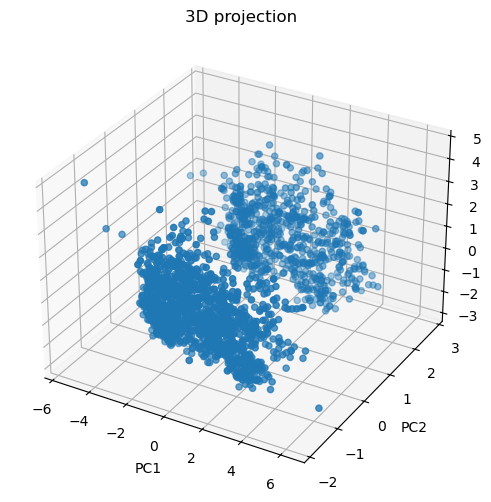

In [79]:

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D projection")

# Model -> KMeans 

## 1. Elbow Method

In [80]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [81]:
knee = KneeLocator(range(1, 11), wcss,curve="convex", direction="decreasing")

optimal_k = knee.elbow

print("Best K Value :", optimal_k)

Best K Value : 4


Text(0.5, 0, 'wcss')

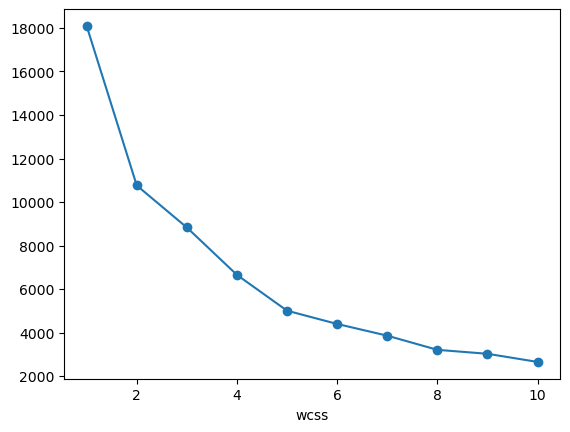

In [82]:
# let's try to see elbow value by ourself even if we alredy have the best k value

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("K")
plt.xlabel("wcss")

## 2. Silhouette Score

In [83]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

Text(0.5, 0, 'Scores')

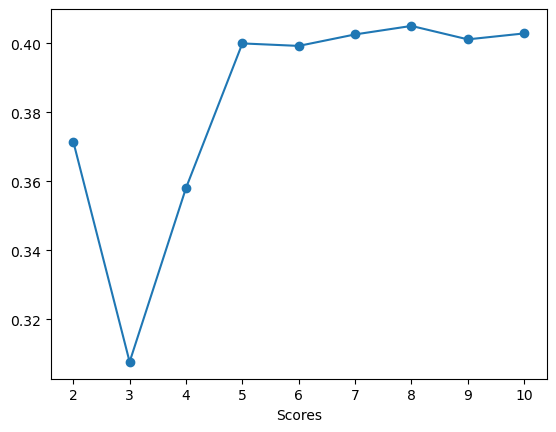

In [84]:
plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("K")
plt.xlabel("Scores")

Text(0, 0.5, 'Score')

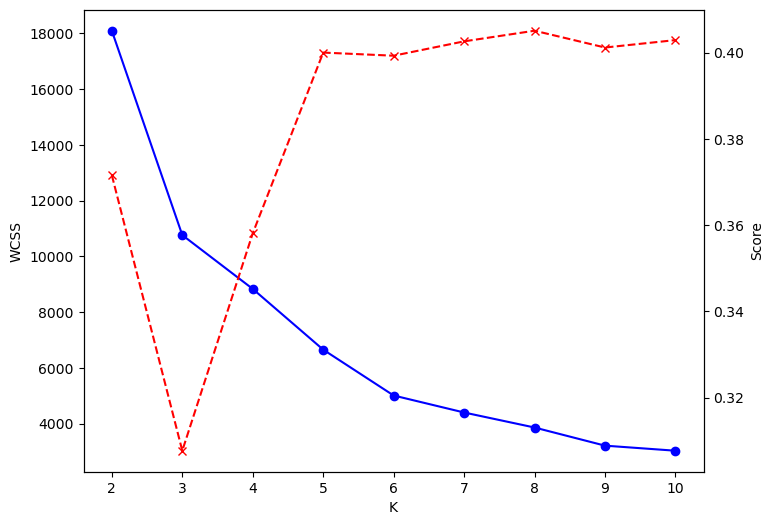

In [85]:
# Combined plot -> both tyhe lines od  wcss and silhouette_score meets is the best k value 

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("Score")

# Both lines are intesecting somewhere around k = 4

In [86]:
best_model = KMeans(n_clusters=4, random_state=42)
labels = best_model.fit_predict(X_pca)

<Axes: >

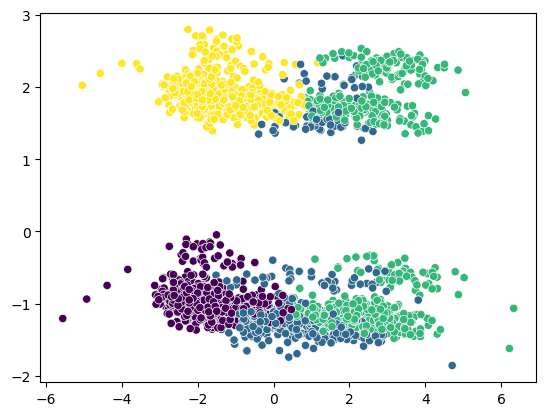

In [87]:
# 2D plot

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], c=labels)

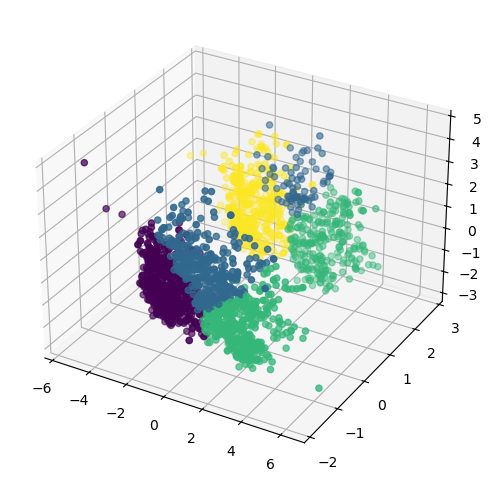

In [88]:
# 3D plot

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels)

# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_zlabel("PC3")
# ax.set_title("3D projection")

In [89]:
from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg =  agg_clf.fit_predict(X_pca)

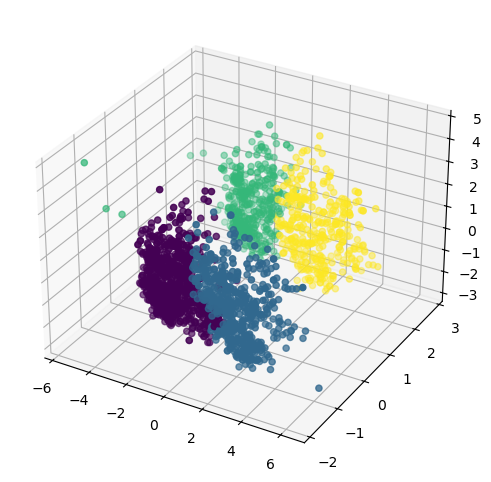

In [90]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

##### * We can clearly seee that AgglomerativeClustering hass better cluster sepration than KMeans . So, we will use agglomeretive further

## Characterization of Clusters

In [91]:
X["Cluster"] = labels_agg

In [92]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Childrean,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Cluster', ylabel='count'>

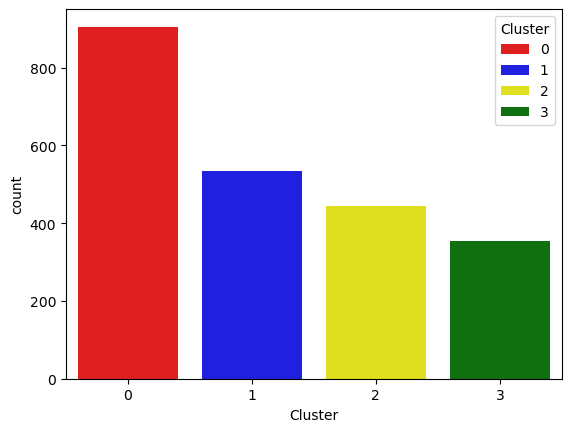

In [93]:
pal = ['red', "blue", "yellow", 'green']

sns.countplot(x=X["Cluster"], palette=pal, hue=X["Cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

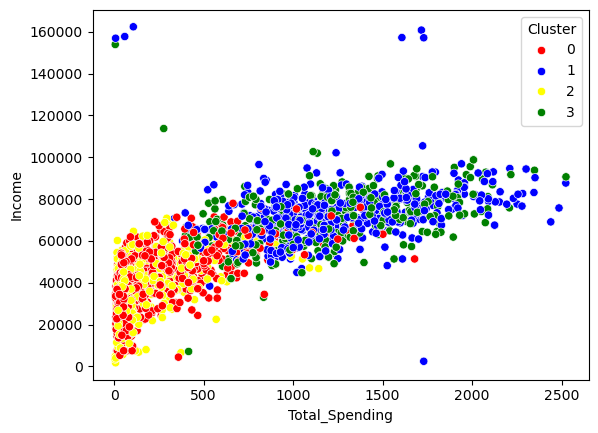

In [94]:
# we will check one of the heigest co-relations -> Income & Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X['Income'], hue=X['Cluster'], palette=pal)

### Note 
#####     Cluster0 : Red,   Cluster1 : Blue,    Cluster2 : Yellow,  Cluster3 : Green
#####     &
#####     "↑" represents ~ High,    "↓" represents ~ Low

### Obeservations :
#####     Premium Customers : Cluster1 & Cluster3 , Because : Total_Spending ↑ & Income ↑
#####     Normal Customers : Cluster0 & Cluster2 , Because : Total_Spending ↓ & Income ↓

In [95]:
cluster_summary = X.groupby("Cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
Cluster         

## Cluster Observations

| **Cluster 0** | **Cluster 1** |
|---|---|
| - ↓ income<br>- ↓ Web, Catlog & Store Purchases<br>- ↓ Age<br>- ↓ spending<br>- ↑ NumWebVisitsMonth<br>- ↑ Total_Childrean<br>- Partners | - ↑ income<br>- ↑ Web, Catlog & Store Purchases<br>- ↑ Age<br>- ↑ spending<br>- ↓ NumWebVisitsMonth<br>- ↓ Total_Childrean<br>- Partners |
| **Cluster 2** <br>- ↓ income<br>- ↓ Web, Catlog & Store Purchases<br>- ↓ Age<br>- ↓ spending<br>- ↑ NumWebVisitsMonth<br>- ↑ Total_Childrean<br>- Alone | **Cluster 3** <br>- ↑ income<br>- ↑ Web, Catlog & Store Purchases<br>- ↑ Age<br>- ↑ spending<br>- ↓ NumWebVisitsMonth<br>- ↓ Total_Childrean<br>- Alone<br>- ↑↑ Response |
